# JaxFEM – Einstieg
Dieses Notebook löst ein einfaches **Poisson-Problem** auf einem 2D-Rechteckgitter
und zeigt das Ergebnis direkt hier im Notebook an.

In [7]:
# Pakete laden
import jax
import jax.numpy as np
import os
import matplotlib.pyplot as plt

from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.generate_mesh import get_meshio_cell_type, Mesh, rectangle_mesh

print('JAX-Version:', jax.__version__)

JAX-Version: 0.6.2


## 1. Problem definieren
Wir lösen −∇·(∇u) = f mit einer Gaußschen Quellterm-Funktion f in der Mitte des Gebiets.

In [8]:
class Poisson(Problem):
    def get_tensor_map(self):
        return lambda x: x

    def get_mass_map(self):
        def mass_map(u, x):
            val = -np.array([10*np.exp(-(np.power(x[0] - 0.5, 2) + np.power(x[1] - 0.5, 2)) / 0.02)])
            return val
        return mass_map

## 2. Netz erzeugen
32×32 Viereck-Elemente auf dem Einheitsquadrat [0,1]²

In [9]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Lx, Ly = 1., 1.
meshio_mesh = rectangle_mesh(Nx=32, Ny=32, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
print('Knoten:', len(meshio_mesh.points), '  Elemente:', len(meshio_mesh.cells_dict[cell_type]))

Knoten: 1089   Elemente: 1024


## 3. Randbedingungen (Dirichlet u=0 an allen Rändern)

In [10]:
def left(point):   return np.isclose(point[0], 0.,  atol=1e-5)
def right(point):  return np.isclose(point[0], Lx,  atol=1e-5)
def bottom(point): return np.isclose(point[1], 0.,  atol=1e-5)
def top(point):    return np.isclose(point[1], Ly,  atol=1e-5)
def zero(point):   return 0.

dirichlet_bc_info = [[left, right, bottom, top], [0]*4, [zero]*4]

## 4. Lösen

In [11]:
problem = Poisson(mesh=mesh, vec=1, dim=2, ele_type=ele_type, dirichlet_bc_info=dirichlet_bc_info)
sol = solver(problem)
print('Lösung berechnet. Shape:', sol[0].shape)

[04-24 16:21:08][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-24 16:21:08][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[04-24 16:21:08][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[04-24 16:21:08][DEBUG] jax_fem: Done pre-computations, took 0.010938882827758789 [s]
[04-24 16:21:08][INFO] jax_fem: Solving a problem with 1024 cells, 1089x1 = 1089 dofs.
[04-24 16:21:08][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.
[04-24 16:21:08][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-24 16:21:08][DEBUG] jax_fem: Start timing
[04-24 16:21:08][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-24 16:21:08][DEBUG] jax_fem: Function split_and_compute_cell took 0.0590 seconds
[04-24 16:21:08][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-24 16:21:08][DEBUG] jax_fem: Before, l_2 res = 0.05494385811255661, relative l

Lösung berechnet. Shape: (1089, 1)


## 5. Ergebnis visualisieren

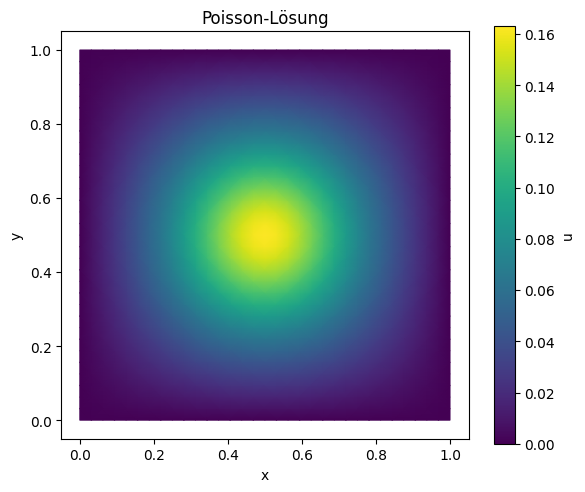

In [12]:
points = meshio_mesh.points
u = sol[0].flatten()

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.tripcolor(points[:, 0], points[:, 1], u, shading='gouraud', cmap='viridis')
plt.colorbar(sc, ax=ax, label='u')
ax.set_title('Poisson-Lösung')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()